In [1]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.tri as tri
from matplotlib.path import Path
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import MFO
plt.rcParams['font.sans-serif']=['SimHei'] #用来正常显示中文标签
plt.rcParams['axes.unicode_minus']=False #用来正常显示负号
print("环境创建成功！")

环境创建成功！


In [2]:
# 判断多边形是否为凸多边形
def is_convex_polygon(sorted_polygon_points):
    n = len(sorted_polygon_points)
    signs = []
    for i in range(n):
        p1, p2, p3 = (
            sorted_polygon_points[i],
            sorted_polygon_points[(i + 1) % n],
            sorted_polygon_points[(i + 2) % n],
        )
        cross_product = (p2[0] - p1[0]) * (p3[1] - p1[1]) - (p2[1] - p1[1]) * (p3[0] - p1[0])
        signs.append(np.sign(cross_product))
    # 如果所有点的叉积符号相同，则为凸多边形
    return all(s > 0 for s in signs) or all(s < 0 for s in signs)

# 排列节点顺序
def sort_connected_points(x, y, node_index, connected_points):
    connected_x = x[connected_points]
    connected_y = y[connected_points]
    angles = np.arctan2(connected_y - y[node_index], connected_x - x[node_index])  # 计算与指定节点连线的角度
    sorted_indices = np.argsort(angles)  # 根据角度从小到大排序
    return connected_points[sorted_indices], np.column_stack((connected_x[sorted_indices], connected_y[sorted_indices]))

# 定义目标函数：节点与相邻节点连线的长度总和
def objective_function(position, neighbors):
    """
    目标函数，计算指定节点与相邻节点的距离总和
    :param position: 节点的新位置 (x, y)
    :param neighbors: 相邻节点的坐标列表 [(x1, y1), (x2, y2), ...]
    :return: 距离总和
    """
    distances = [np.linalg.norm(np.array(position) - np.array(neighbor)) for neighbor in neighbors]
    return sum(distances)

# 在多边形内部随机移动节点
def move_within_polygon(x, y, node_index, polygon_path):
    while True:
        new_x = x[node_index] + (np.random.rand() - 0.5) * 0.2
        new_y = y[node_index] + (np.random.rand() - 0.5) * 0.2
        if polygon_path.contains_point((new_x, new_y)):
            x[node_index] = new_x
            y[node_index] = new_y
            break

print("函数创建成功！")

函数创建成功！


In [3]:
# 修改节点移动部分，使用飞蛾扑火优化算法
def optimize_node_position(initial_position, neighbors, polygon_path, lb, ub, max_iter=100, pop=50):
    """
    使用飞蛾扑火优化算法优化节点位置
    :param initial_position: 节点的初始位置 (x, y)
    :param neighbors: 相邻节点的坐标列表 [(x1, y1), (x2, y2), ...]
    :param polygon_path: 多边形区域的 Path 对象，用于限制节点移动范围
    :param lb: 下边界 (x_min, y_min)
    :param ub: 上边界 (x_max, y_max)
    :param max_iter: 最大迭代次数
    :param pop: 种群数量
    :return: 优化后的节点位置
    """

    # 定义适应度函数
    def fitness_function(X):
        position = (X[0], X[1])
        # 如果位置不在多边形内，返回一个非常大的值作为惩罚
        if not polygon_path.contains_point(position):
            return 1e10
        return objective_function(position, neighbors)

    # 维度为2 (x, y)
    dim = 2
    lb = np.array(lb)  # 转为 NumPy 数组
    ub = np.array(ub)

#     # 调用MFO算法
#     best_fitness, best_position, _ = MFO.MFO(pop, dim, lb, ub, max_iter, fitness_function)
    best_fitness, best_position, fitness_curve = MFO.MFO(pop, dim, lb, ub, max_iter, fitness_function)

    return best_position.flatten(),fitness_curve  # 返回优化后的节点位置

print("节点移动函数创建成功！")

节点移动函数创建成功！


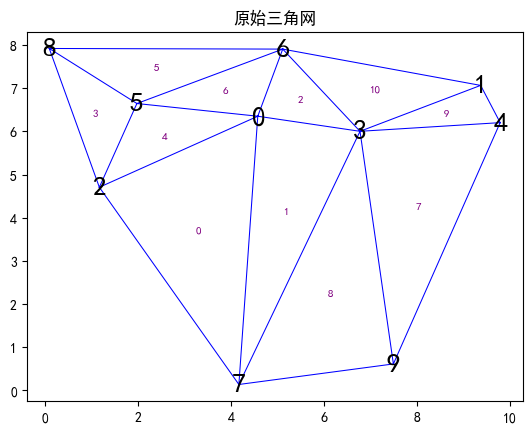

In [32]:
# 设置不规则三角网的大小
n_points = 10
x = 10*np.random.rand(n_points)
y = 10*np.random.rand(n_points)

# 生成初始三角网
triangulation = tri.Triangulation(x, y)
plt.triplot(triangulation, color="blue", linewidth=0.75, label="原始三角网")
plt.title("原始三角网")
# 显示所有节点的索引
for i in range(len(x)):
    plt.text(x[i], y[i], str(i), color="black", fontsize=20, ha="center", va="center")

# 显示三角形索引
for i, triangle in enumerate(triangulation.triangles):
    triangle_points = np.array([x[triangle], y[triangle]]).T
    centroid = np.mean(triangle_points, axis=0)  # 计算三角形质心
    plt.text(centroid[0], centroid[1], str(i), color="purple", fontsize=8, ha="center", va="center")

In [33]:
# 找到边界点（这一步只需运行一次）
triangles = triangulation.triangles
edges = set()  # 使用集合来存储边
for triangle in triangles:
    # 每个三角形有3条边，边可以按任意顺序表示
    edges.add(tuple(sorted([triangle[0], triangle[1]])))
    edges.add(tuple(sorted([triangle[1], triangle[2]])))
    edges.add(tuple(sorted([triangle[2], triangle[0]])))

boundary_edges = []
# 统计每条边出现的次数，只有出现一次的边是边界
for edge in edges:
    # 计算当前边在所有三角形中出现的次数
    count = 0
    for triangle in triangles:
        # 检查边是否出现在该三角形的三条边中
        for i, j in [(0, 1), (1, 2), (2, 0)]:
            if edge == tuple(sorted([triangle[i], triangle[j]])):
                count += 1
                break
    if count == 1:  # 如果该边只出现一次，则为边界边
        boundary_edges.append(edge)
        
# 从边界边中提取出边界上的节点
boundary_points = set()
for edge in boundary_edges:
    boundary_points.update(edge)

print(f"边界点索引：{boundary_points}")

边界点索引：{1, 2, 4, 6, 7, 8, 9}


In [34]:
# 用户指定三角形索引
triangle_index = 1  # 示例三角形索引
selected_triangle = triangulation.triangles[triangle_index]
print("选择的三角形顶点索引：", selected_triangle)

# 选择符合条件的顶点
valid_node = None
min_edges = float("inf")

for node in selected_triangle:
    print(node)
    if node in boundary_points:
        continue  # 跳过边界点
    
    # 获取相连的节点集合
    connected_points = set()
    for triangle in triangulation.triangles:
        if node in triangle:
            connected_points.update(triangle)
    connected_points.discard(node)  # 排除自身
    connected_points = np.array(list(connected_points))

    # 排列节点顺序
    sorted_connected_points, sorted_polygon_points = sort_connected_points(x, y, node, connected_points)
    print(sorted_connected_points)
    # 验证是否为凸多边形
    if not is_convex_polygon(sorted_polygon_points):
        continue  # 跳过非凸多边形
    
    # 检查相连边的数量
    if len(sorted_connected_points) <= min_edges:
        min_edges = len(sorted_connected_points)
        valid_node = node

if valid_node is None:
    raise ValueError("没有符合条件的顶点！")

print(f"选择的移动顶点索引：{valid_node}")
print(sorted_connected_points)

选择的三角形顶点索引： [3 0 7]
3
[7 9 4 1 6 0]
0
[2 7 3 6 5]
7
选择的移动顶点索引：0
[2 7 3 6 5]


In [35]:
# 优化节点位置
polygon_path = Path(sorted_polygon_points)
initial_position = (x[valid_node], y[valid_node])
neighbors = list(zip(sorted_polygon_points[:, 0], sorted_polygon_points[:, 1]))
lb = [sorted_polygon_points[:, 0].min(), sorted_polygon_points[:, 1].min()]
ub = [sorted_polygon_points[:, 0].max(), sorted_polygon_points[:, 1].max()]

# optimized_position = optimize_node_position(initial_position, neighbors, polygon_path, lb, ub)
optimized_position, fitness_curve = optimize_node_position(initial_position, neighbors, polygon_path, lb, ub)

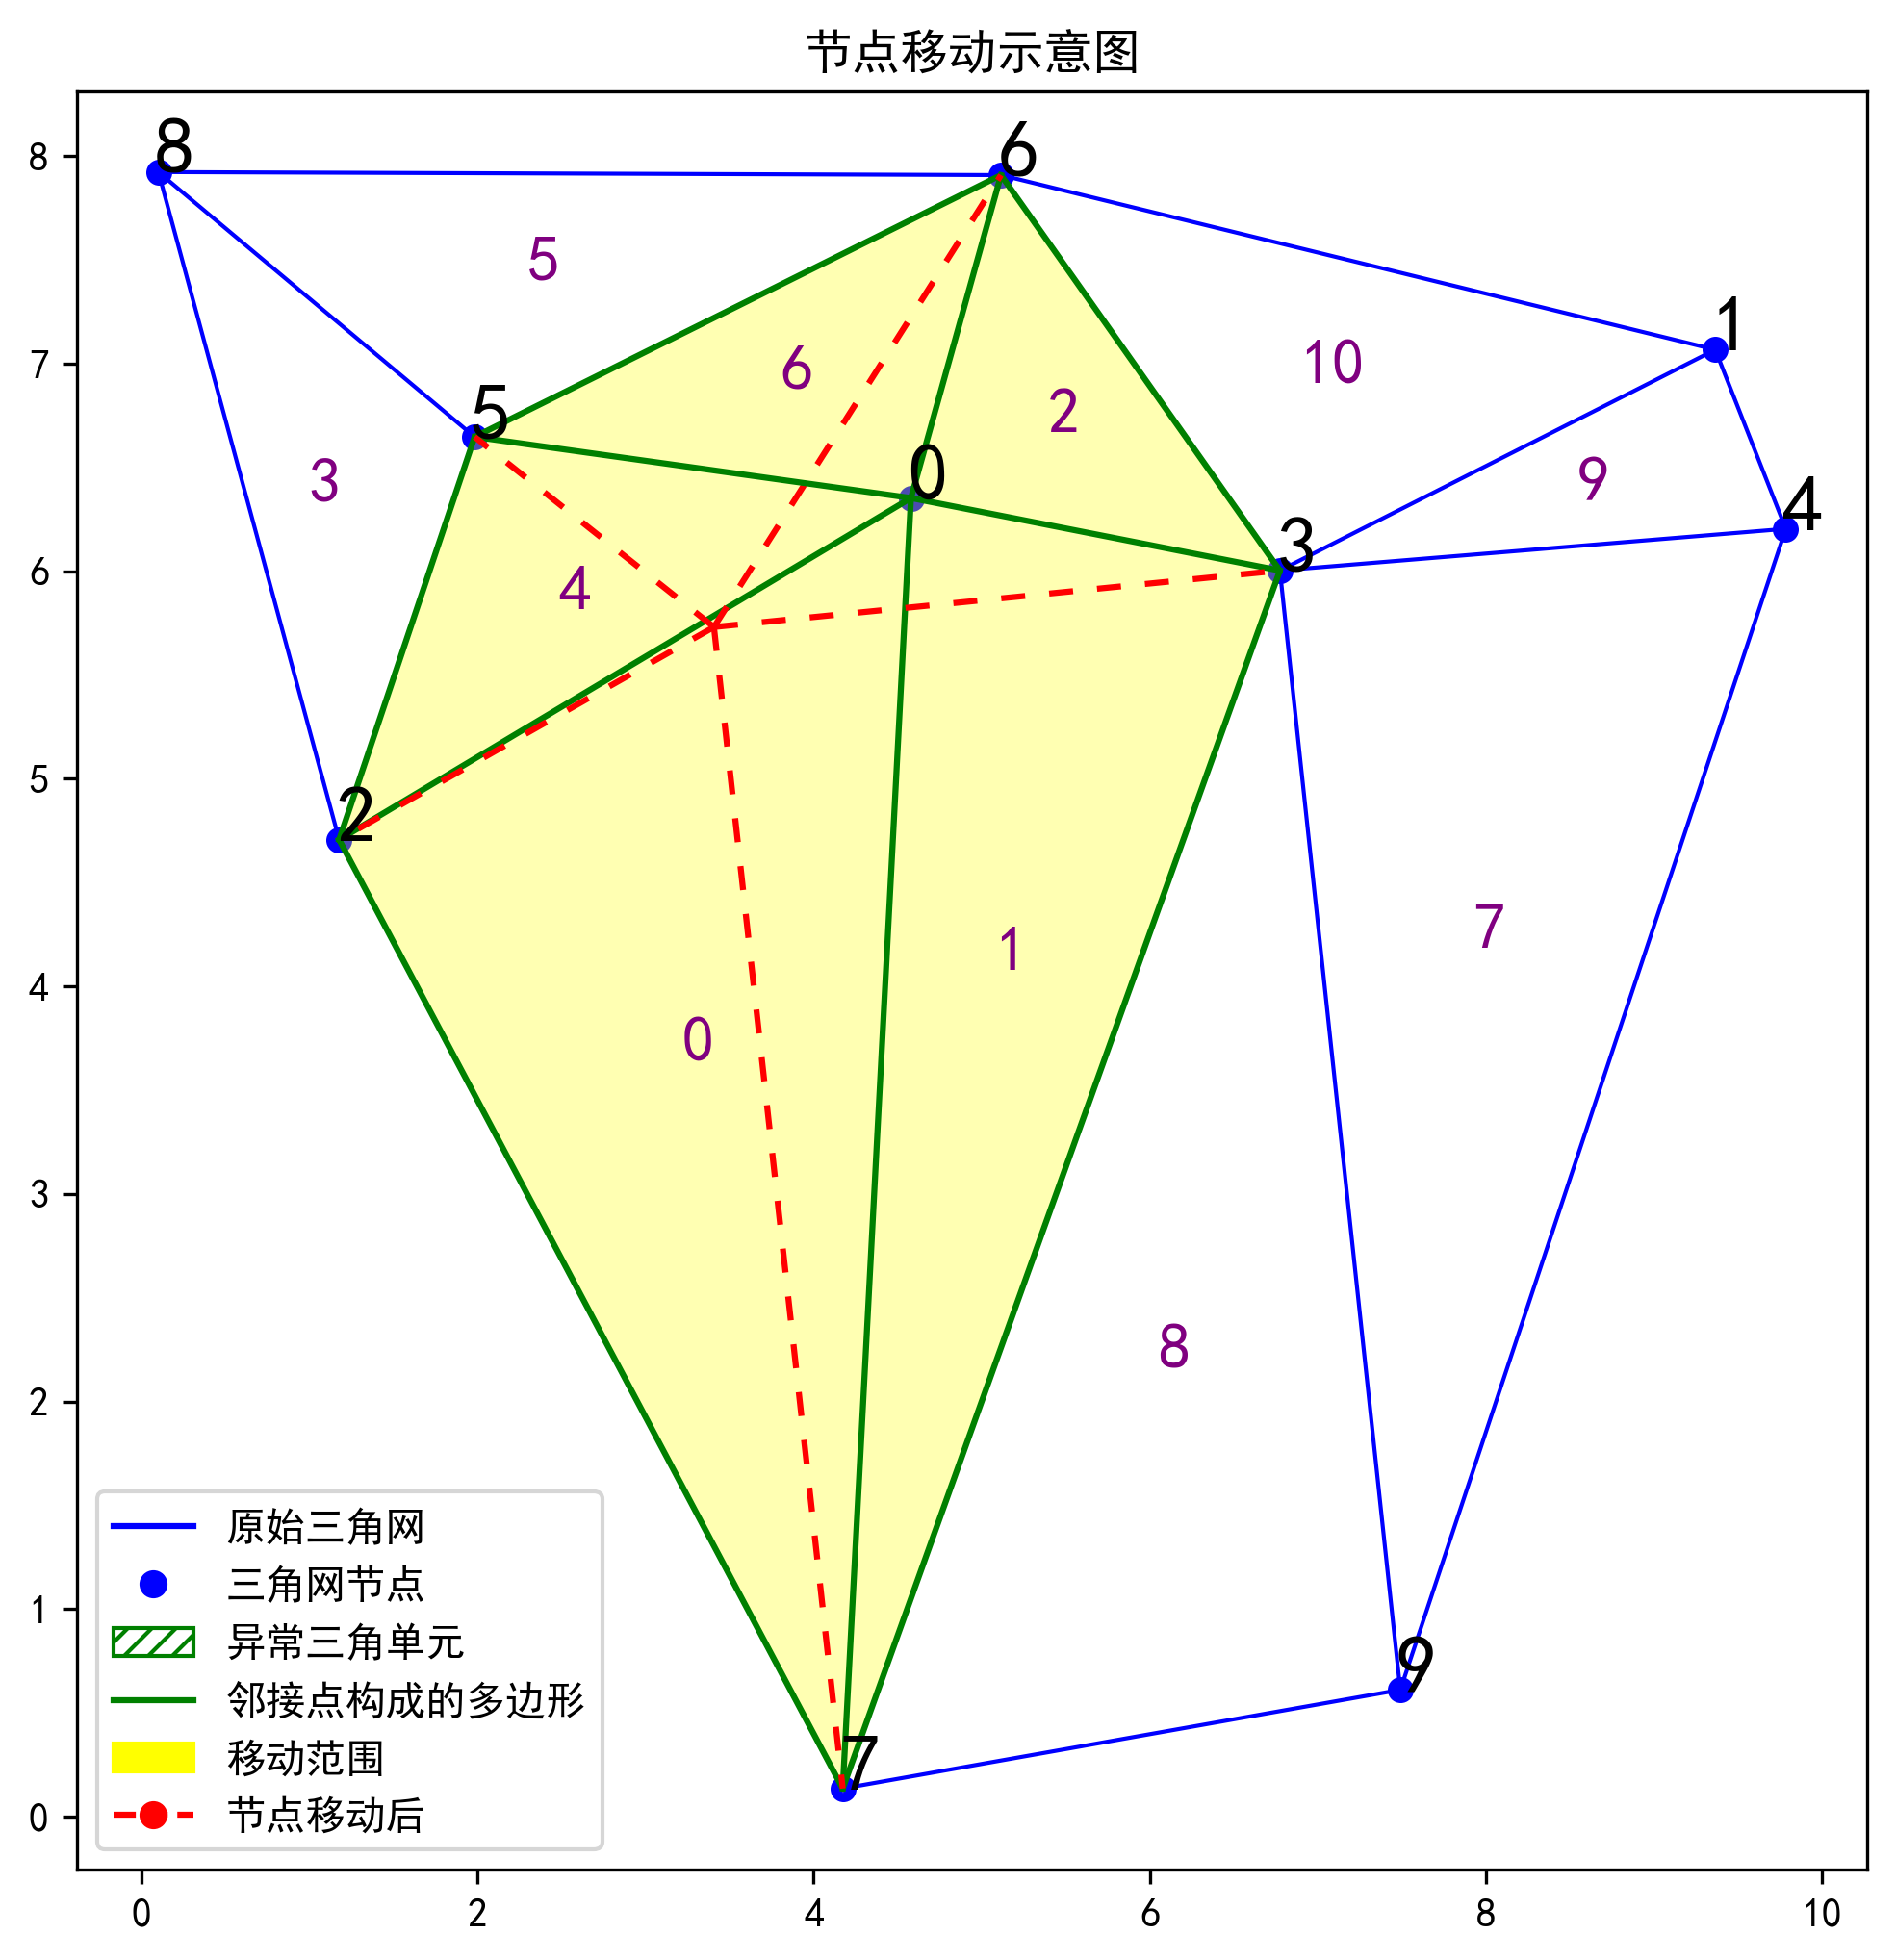

In [74]:
# 绘图
plt.figure(figsize=(8, 8),dpi=300)
plt.triplot(triangulation, color="blue", linewidth=1, label="原始三角网")

# 显示所有节点的索引
for i in range(len(x)):
    plt.text(x[i]+0.1, y[i]+0.1, str(i), color="black", fontsize=20, ha="center", va="center")
    plt.scatter(x[i], y[i], color='b',s=30)

plt.plot(np.append(sorted_polygon_points[:, 0], sorted_polygon_points[0, 0]), # 添加第一个点的x坐标到最后
        np.append(sorted_polygon_points[:, 1], sorted_polygon_points[0, 1]),  # 添加第一个点的y坐标到最后
        'g', label="相邻节点构成的多边形")  # 确保多边形闭合
plt.fill(np.append(sorted_polygon_points[:, 0], sorted_polygon_points[0, 0]),
        np.append(sorted_polygon_points[:, 1], sorted_polygon_points[0, 1]),
        color='yellow', alpha=0.3, label="移动范围")

for neighbor in neighbors:
    # 初始连线
    pltl4=plt.plot([initial_position[0], neighbor[0]], [initial_position[1], neighbor[1]], linestyle='-',color='g',label="移动前",)
    distance = np.linalg.norm(np.array(initial_position) - np.array(neighbor))
    midpoint = ((initial_position[0] + neighbor[0]) / 2, (initial_position[1] + neighbor[1]) / 2)
#     plt.text(midpoint[0], midpoint[1], f"{distance:.2f}", color="red", fontsize=8)
    # 优化后连线
    pltl5=plt.plot([optimized_position[0], neighbor[0]], [optimized_position[1], neighbor[1]], 'r--',dashes=[4,4], label="移动后")
    distance = np.linalg.norm(np.array(optimized_position) - np.array(neighbor))
    midpoint = ((optimized_position[0] + neighbor[0]) / 2, (optimized_position[1] + neighbor[1]) / 2)
#     plt.text(midpoint[0], midpoint[1], f"{distance:.2f}", color="green", fontsize=8)

# 计算初始和优化后的总长度
initial_total_length = sum([np.linalg.norm(np.array(initial_position) - np.array(neighbor)) for neighbor in neighbors])
optimized_total_length = sum([np.linalg.norm(np.array(optimized_position) - np.array(neighbor)) for neighbor in neighbors])
# plt.plot(initial_position[0], initial_position[1], 'ro', label=f"初始位置 (总长度={initial_total_length:.4f})")
# plt.plot(optimized_position[0], optimized_position[1], 'bo', label=f"优化后位置 (总长度={optimized_total_length:.4f})")


# 显示三角形编号   
for i, triangle in enumerate(triangulation.triangles):
    triangle_points = np.array([x[triangle], y[triangle]]).T
    centroid = np.mean(triangle_points, axis=0)  # 计算三角形质心
    plt.text(centroid[0], centroid[1], str(i), color="purple", fontsize=16, ha="center", va="center")
    
# 创建自定义图例元素
line1 = mlines.Line2D([], [], color='b', label='原始三角网')
# 创建一个代表点的图例项
# circle = mpatches.Circle((0, 0), radius=0.005, color='b', label='三角网节点')
line0 = mlines.Line2D([], [], marker='o', color='b', label='三角网节点', linestyle='None', markersize=6)
line2 = mlines.Line2D([], [], color='g', label='邻接点构成的多边形')
line3 = mlines.Line2D([], [], color='r', label='节点移动后', linestyle="--", marker='o')
patch = mpatches.Patch(color='yellow', label='移动范围')
# 创建一个带斜线填充的三角形
trianglelg = mpatches.Polygon([(0, 0), (1, 0), (0.5, 1)], closed=True, facecolor='none', edgecolor='green', hatch='////', label='异常三角单元')
# # 创建一个矩形，边框和斜线填充都为绿色
# rect = mpatches.Rectangle((0, 0), 1, 1, facecolor='none', edgecolor='green', hatch='\\', label='异常三角单元')
# 显示自定义图例
plt.legend(handles=[line1, line0, trianglelg,line2, patch, line3])
#plt.legend()
plt.title("节点移动示意图")
plt.show()

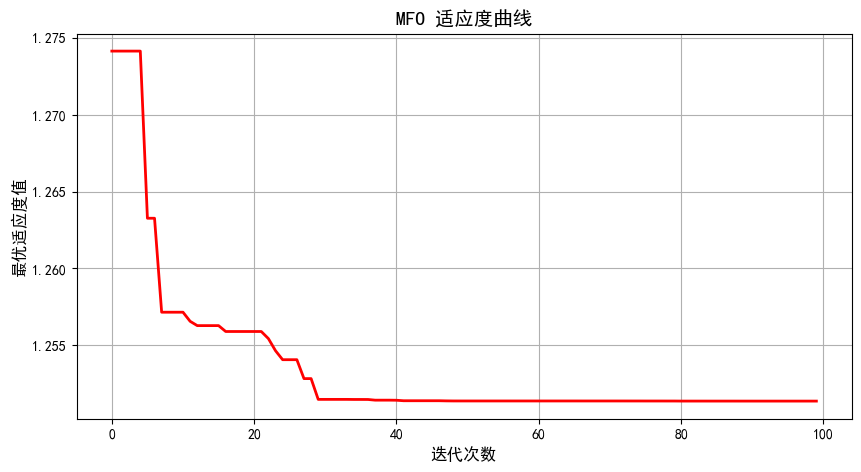

In [49]:
# 绘制适应度曲线
plt.figure(figsize=(10, 5))
plt.plot(fitness_curve, 'r-', linewidth=2)
plt.xlabel('迭代次数', fontsize=12)
plt.ylabel('最优适应度值', fontsize=12)
plt.title('MFO 适应度曲线', fontsize=14)
plt.grid()
plt.show()

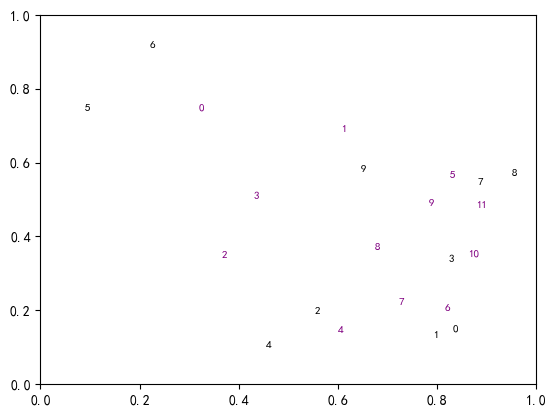

In [19]:
# 显示所有节点的索引
for i in range(len(x)):
    plt.text(x[i], y[i], str(i), color="black", fontsize=8, ha="center", va="center")

# 显示三角形索引
for i, triangle in enumerate(triangulation.triangles):
    triangle_points = np.array([x[triangle], y[triangle]]).T
    centroid = np.mean(triangle_points, axis=0)  # 计算三角形质心
    plt.text(centroid[0], centroid[1], str(i), color="purple", fontsize=8, ha="center", va="center")